-  Karras pre-conditioning
- inspired by this [paper](https://arxiv.org/abs/2206.00364)

# Load deps

In [ ]:
# ! pip install -q torcheval

In [ ]:
# # # if src modules imported
# # from google.colab import drive
# # drive.mount('/content/drive')
# import sys
# app_path = '/content/drive/MyDrive/Projects/miniSD'
# sys.path.append(app_path)

In [ ]:
import os, torch
import matplotlib as mpl
import matplotlib.pyplot as plt
import torchvision.transforms.functional as TF
import torch.nn.functional as F
from pathlib import Path
import seaborn as sns
from torch.utils.data import DataLoader,default_collate
from torch import nn,tensor
from datasets import load_dataset
from functools import partial
from torch.optim import lr_scheduler
from torch import optim
from fastprogress import progress_bar
from diffusers import UNet2DModel
from scipy import integrate

from src.utils import set_seed
from src.init import clean_mem
from src.datasets import DataLoaders, inplace, show_images
from src.diffusion import init_ddpm
from src.learner import DeviceCB, ProgressCB, MetricsCB, Learner
from src.accel import MixedPrecision
from src.sgd import BatchSchedCB
from src.fid import ImageEval

# Config

In [ ]:
mpl.rcParams['image.cmap'] = 'gray_r'
mpl.rcParams['figure.dpi'] = 70
torch.set_printoptions(precision=2, linewidth=140, sci_mode=False)
dataset_xl,dataset_yl = 'image','label'
dataset_name = "zalando-datasets/fashion_mnist"
bs = 512
lr = 1e-2
epochs = 10
n_steps = 1000
models_path = Path("artifacts/models")
models_path.mkdir(exist_ok=True, parents=True)
os.environ['CUDA_VISIBLE_DEVICES']='1'
set_seed(42)

# Load dataset

In [ ]:
@inplace
def transformi(b):
    b[dataset_xl] = [
        F.pad(TF.to_tensor(o), (2,2,2,2))*2-1
        #  as mentioned in paper's appendix C
        # image data is always represented in the continuous range [−1, 1]
        for o in b[dataset_xl]
    ]

dsd = load_dataset(dataset_name)
tds = dsd.with_transform(transformi)
dls = DataLoaders.from_dd(tds, bs)

dl = dls.train
xb,yb = b = next(iter(dl))

sig_data = xb.std()
print(f"xb.std: {sig_data}")

- `y` is clean signal, `n` is `N(0,1)` noise.
- $\sigma$ here is what we had as $\bar{\alpha}$ previosuly

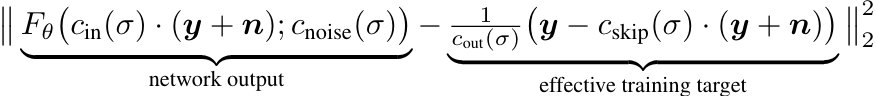

The reason for this is:
- we can either predict the noise or the image given a noisy input (image + noise)
- if given a pure noise, predicting the noise is too easy and the model doesn't learn well
- if given the input image with a very small amount of noise, predicting the image is a waste of time
- so we want the model to solve an equally difficult task given the ratio of noise and image in the noisy input. that's how this karras idea works.
    - $c_{skip}$ controls this in the `effective training target` above
- the formulas (below) to calculate coefficients are explained in appendix B6 of the [karras et al.](https://arxiv.org/abs/2206.00364) paper
    - one major goal is to keep input and target at unit variance

In [ ]:
def scalings(sig):
    totvar = sig**2+sig_data**2
    c_skip = sig_data**2/totvar
    c_out = sig*sig_data/totvar.sqrt()
    c_in = 1/totvar.sqrt()
    if torch.isnan(c_skip).any() or torch.isnan(c_out).any() or torch.isnan(c_in).any():
        nan_str_skip = f"c_skip={sig[torch.isnan(c_skip)]}"
        nan_str_out = f"c_out={sig[torch.isnan(c_out)]}"
        nan_str_in = f"c_in={sig[torch.isnan(c_in)]}"
        print(f"found NaN values --> {nan_str_skip}, {nan_str_out}, {nan_str_in}")
    return c_skip,c_out,c_in

the image below shows:
- when the $\sigma$ is too small or too large, the trained model performs poorly
- only when we have a medium $\sigma$, does the model peform well

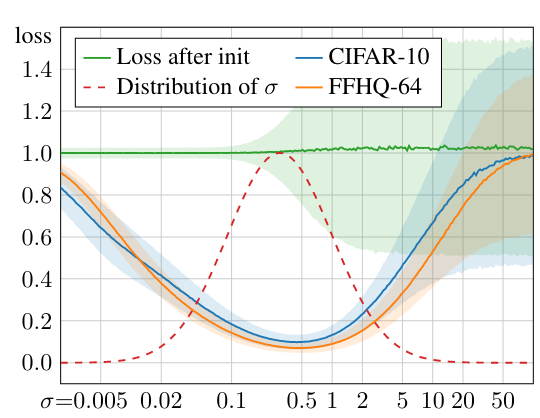

In [ ]:
sig_samp = (torch.randn([10000])*1.2-1.2).exp()
# this is a log-normal distribution
# the distribution parameters are from the paper,
# chosen in a way to have sigmas >=1 with probability of 1/3
fig, axs = plt.subplots(1,2, figsize=(14,6))
axs[0].hist(sig_samp, bins=20);
sns.kdeplot(sig_samp, clip=(0,10), ax=axs[1]);

In [ ]:
def noisify(x0):
    device = x0.device
    sig = (torch.randn([len(x0)])*1.2-1.2).exp().to(x0).reshape(-1,1,1,1)
    noise = torch.randn_like(x0, device=device)
    c_skip,c_out,c_in = scalings(sig)
    noised_input = x0 + noise*sig
    target = (x0-c_skip*noised_input)/c_out
    return (noised_input*c_in,sig.squeeze()),target
def collate_ddpm(b): return noisify(default_collate(b)[dataset_xl])
def dl_ddpm(ds): return DataLoader(
    ds, batch_size=bs,
    collate_fn=collate_ddpm,
    num_workers=os.cpu_count()
)

In [ ]:
dls = DataLoaders(dl_ddpm(tds['train']), dl_ddpm(tds['test']))
dl = dls.train
(noised_input,sig),target = b = next(iter(dl))

In [ ]:
# this is what input images look like
show_images(noised_input[:16], imsize=1.5, titles=list(sig.cpu().numpy().round(3)[:16]));

In [ ]:
# this is what the target looks like based on the amount of noise (sigma)
show_images(target[:16], imsize=1.5, titles=list(sig.cpu().numpy().round(3)[:16]));

In [ ]:
print(f"noised_input.mean: {noised_input.mean()}")
print(f"noised_input.std: {noised_input.std()}")
print(f"target.mean: {target.mean()}")
print(f"target.std: {target.std()}")
# karras dosn't do anything to have zero mean.
# all it cares about is unit variance.
# so the mean might not be zero

# Train

In [ ]:
clean_mem()

In [ ]:
class UNet(UNet2DModel):
    def forward(self, x): return super().forward(*x).sample

opt_func = partial(optim.Adam, eps=1e-5)
tmax = epochs * len(dls.train)
sched = partial(lr_scheduler.OneCycleLR, max_lr=lr, total_steps=tmax)
model = UNet(in_channels=1, out_channels=1, block_out_channels=(32, 64, 128, 256), norm_num_groups=8)
init_ddpm(model)

cbs = [DeviceCB(), MixedPrecision(), ProgressCB(plot=True), MetricsCB(), BatchSchedCB(sched)]

In [ ]:
# from src.activations import ActivationStats
# astats = ActivationStats(lambda mod: isinstance(mod, nn.SiLU))
# cbs=cbs+[astats]
# # doesn't work. because it lead to OOM:))))))))))))))
# TODO: fix astats and make sure to useit here.
# because even though the NaN problem is fixed with grad_clip_norm,
# this might not be the best learning curve or the most stable and convergent training

In [ ]:
learn = Learner(model, dls, nn.MSELoss(), lr=lr, cbs=cbs, opt_func=opt_func)

In [ ]:
# learn.fit(epochs)

In [ ]:
# torch.save(learn.model, models_path / 'fashion_karras.pkl')

# Visually inspect predictions

In [ ]:
model = learn.model = torch.load(models_path / 'fashion_karras.pkl', weights_only=False).cuda()

In [ ]:
def denoise(target, noised_input): return target*c_out + noised_input*c_skip

with torch.no_grad():
    sigr = sig.cuda().reshape(-1,1,1,1)
    c_skip,c_out,c_in = scalings(sigr)
    targ_pred = learn.model((noised_input.cuda(),sig.cuda()))
    x0_pred = denoise(targ_pred, noised_input.cuda()/c_in)

In [ ]:
show_images(noised_input[:16], imsize=1.5, titles=list(sig.cpu().numpy().round(3)[:16],));

In [ ]:
# predictions
show_images(x0_pred[:16].clamp(-1,1), imsize=1.5, titles=list(sig.cpu().numpy().round(3)[:16],));

- given that these are just 1-step predictions, they are great

In [ ]:
# actual images
show_images(
    denoise(target.cuda(), noised_input.cuda()/c_in)[:16],
    imsize=1.5, titles=list(sig.cpu().numpy().round(3)[:16],)
);

## how the model takes 1 step from pure noise

In [ ]:
sig_r = tensor(80.).cuda().reshape(-1,1,1,1)
# conventioanlly this is considered pure noise (sigma of 80)
c_skip,c_out,c_in = scalings(sig_r)
x_r = torch.randn(32,1,32,32).to(model.device)*sig_r
with torch.no_grad():
    targ_pred = learn.model((x_r*c_in,sig_r.squeeze()))
    x0_pred = denoise(targ_pred, x_r)
show_images(x0_pred[:16], imsize=1.5);

print(
    x0_pred.max()
    ,x0_pred.min()
    ,x0_pred.mean()
    ,x0_pred.std()
)

- it looks like an unsure interpolation between common possibilties (pants, shoes, etc.)

# Sampling

## Load the reference model, data loader and the evaluator

In [ ]:
from src.augment import get_dropmodel, Dropout
from src.init import GeneralRelu, init_weights
act_gr = partial(GeneralRelu, leak=0.1, sub=0.4)
iw = partial(init_weights, leaky=0.1)
cmodel = get_dropmodel(act_gr, norm=nn.BatchNorm2d, drop=0.1).apply(iw)
loaded_art = torch.load(models_path / 'data_aug2.pkl', weights_only=False)
cmodel.load_state_dict(loaded_art.state_dict())
cmodel = cmodel[:-3]

In [ ]:
bs = 2048
tds = dsd.with_transform(transformi)
# our karras transformation function matches the ones used to train data_aug2 model
dls = DataLoaders.from_dd(tds, bs, num_workers=os.cpu_count())

dt = dls.train
xb,yb = next(iter(dt))

In [ ]:
ie = ImageEval(cmodel, dls, cbs=[DeviceCB()])

## Karras sigma schedule

In [ ]:
def sigmas_karras(n, sigma_min=0.01, sigma_max=80., rho=7., device='cpu'):
    ramp = torch.linspace(0, 1, n)
    min_inv_rho = sigma_min**(1/rho)
    max_inv_rho = sigma_max**(1/rho)
    sigmas = (max_inv_rho + ramp * (min_inv_rho-max_inv_rho))**rho
    return torch.cat([sigmas, tensor([0.])]).to(device)

In [ ]:
sk = sigmas_karras(100)
plt.plot(sk);

- spends much more time fine-tuning the details at the end than compared to the time spent at the start
    - big steps early on and small steps later on
    - error analysis of the $\rho$ parameter is discussed in appendix E1
- this might not be the best idea because the main composition of the image is determined at the beginning

## Define sampler function

In [ ]:
def denoise(model, x, sig):
    c_skip,c_out,c_in = scalings(sig)
    return model((x*c_in, sig))*c_out + x*c_skip

### Euler sampler (deterministic)

In [ ]:
@torch.no_grad()
def sample_euler(x, sigs, i, model):
    sig,sig2 = sigs[i],sigs[i+1]
    denoised = denoise(model, x, sig)
    return x + (x-denoised)/sig*(sig2-sig)

In [ ]:
sz = (bs,1,32,32)
def sample(sampler, model, steps=100, sigma_max=80., **kwargs):
    preds = []
    x = torch.randn(sz).to(model.device)*sigma_max
    sigs = sigmas_karras(steps, device=model.device, sigma_max=sigma_max)
    for i in progress_bar(range(len(sigs)-1)):
        x = sampler(x, sigs, i, model, **kwargs)
        preds.append(x)
    return preds

In [ ]:
preds = sample(sample_euler, model, steps=100)

In [ ]:
s = preds[-1]
print(s.min(),s.max())
show_images(s[:16].clamp(-1,1), imsize=1.5);

In [ ]:
# euler 100
ie.fid(s),ie.kid(s),s.shape